# Exercises for Section 3.3 Introduction to hypothesis testing

This notebook contains the solutions to the exercises
from [Section 3.3 Introduction to hypothesis testing]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (5, 1.6)},
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


$\def\stderr#1{\mathbf{se}_{#1}}$
$\def\stderrhat#1{\hat{\mathbf{se}}_{#1}}$
$\newcommand{\Mean}{\textbf{Mean}}$
$\newcommand{\Var}{\textbf{Var}}$
$\newcommand{\Std}{\textbf{Std}}$
$\newcommand{\Freq}{\textbf{Freq}}$
$\newcommand{\RelFreq}{\textbf{RelFreq}}$
$\newcommand{\DMeans}{\textbf{DMeans}}$
$\newcommand{\Prop}{\textbf{Prop}}$
$\newcommand{\DProps}{\textbf{DProps}}$
$$
\newcommand{\CI}[1]{\textbf{CI}_{#1}}
\newcommand{\CIL}[1]{\textbf{L}_{#1}}
\newcommand{\CIU}[1]{\textbf{U}_{#1}}
\newcommand{\ci}[1]{\textbf{ci}_{#1}}
\newcommand{\cil}[1]{\textbf{l}_{#1}}
\newcommand{\ciu}[1]{\textbf{u}_{#1}}
$$
(this cell contains the macro definitions like $\stderr{\overline{\mathbf{x}}}$, $\stderrhat{}$, $\Mean$, ...)

## Exercises

### E3.23

Compute the $p$-value for hypothesis test of the mean in Batch 05 of the kombucha dataset.

In [6]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample05 = kombucha[kombucha["batch"]==5]["volume"]
len(ksample05)

40

In [7]:
ksample05.head()

107     998.35
108     998.92
109    1005.38
110    1007.20
111    1010.62
Name: volume, dtype: float64

**a)** 
The two competing hypotheses are:
$$ 
  H_0: \mu = \mu_{K_0}
  \qquad\text{and}\qquad
  H_A: \mu \neq \mu_{K_0},
$$
where $\mu_{K_0}=1000$ is the expected mean when the production line is working as expected.

In [9]:
# b) Compute the observed mean
obsmean05 = np.mean(ksample05)
obsmean05

1002.53475

In [11]:
# Population data model under H0
from scipy.stats import norm
rvK0 = norm(1000, 10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# b) Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kbars40 = gen_sampling_dist(rvK0, estfunc=np.mean, n=40)

In [13]:
# c) Compute the p-value of `obsmean05` under H0
obsdev05 = abs(obsmean05 - 1000)
tails = [v for v in kbars40 if abs(v-1000) >= obsdev05]
pvalue05 = len(tails) / len(kbars40)
pvalue05

0.1089

The $p$-value is greater than $\alpha = 0.05$ so we have failed to reject $H_0$.
Batch 05 is OK.

Let's plot the sampling distribution $\overline{\mathbf{K}}_0$
under $H_0$ and the observed sample mean $\overline{\mathbf{k}}_{05}$.

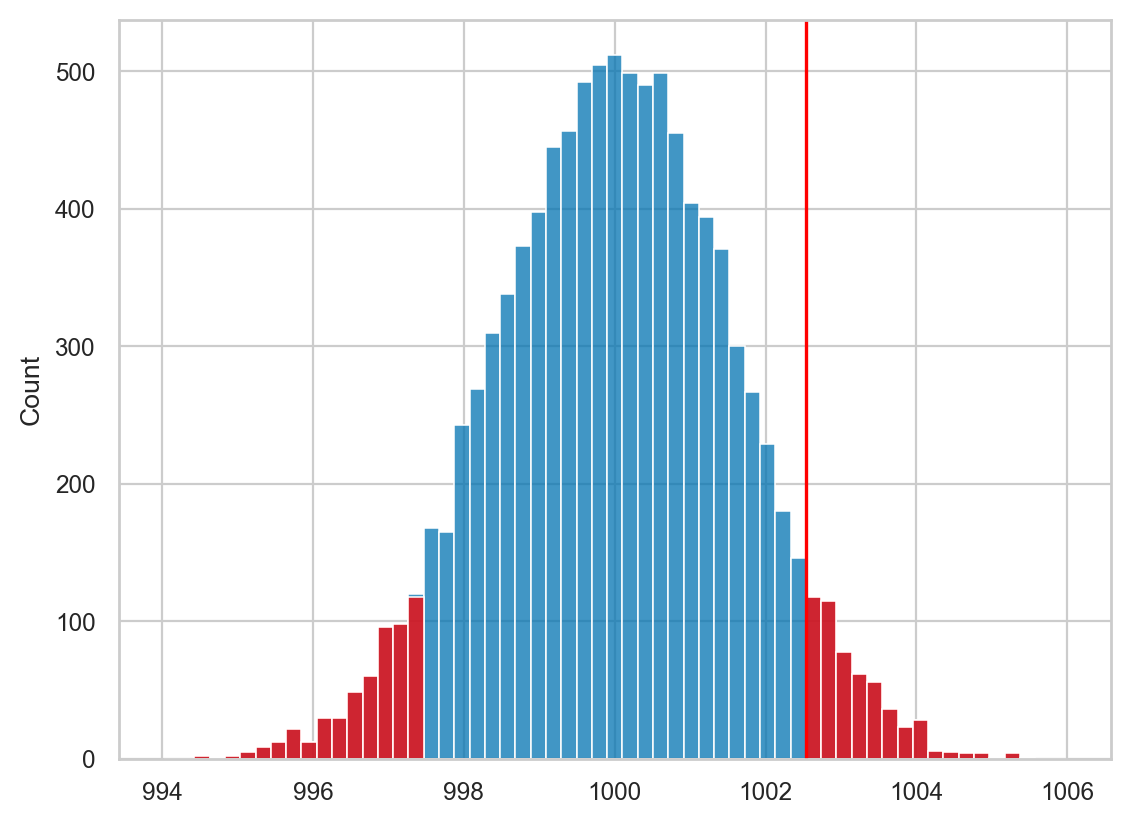

In [14]:
# Choose bins for the histogram aligned with `obsmean05`
from ministats import nicebins
bins = nicebins(kbars40, obsmean05)

# Plot showing `obsmean05` fits within the sampling distribution under H0
sns.histplot(kbars40, bins=bins)
plt.axvline(obsmean05 , color="red")
sns.histplot(tails, bins=bins, color="red");

The function `simulation_test_mean` from the `ministats` library
performs all the steps of the simulation test for the mean.
We can use this function to check we got the above calculations right.

In [15]:
# Set the random seed to the same value as above to reproduce result
np.random.seed(42)

# Check answer using `ministats` helper function
from ministats import simulation_test_mean
simulation_test_mean(ksample05, mu0=1000, sigma0=10)

0.1091

### E3.24

Compute the $p$-value for hypothesis test of the mean in Batch 06 of the kombucha dataset.

In [16]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample06 = kombucha[kombucha["batch"]==6]["volume"]
len(ksample06)

40

In [17]:
ksample06.head()

147     991.88
148    1002.29
149     997.18
150     986.01
151     970.13
Name: volume, dtype: float64

In [19]:
# Compute the observed mean
obsmean06 = np.mean(ksample06)
obsmean06

995.9955

In [21]:
# Population data model under H0
from scipy.stats import norm
rvK0 = norm(1000, 10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(43)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kbars40 = gen_sampling_dist(rvK0, estfunc=np.mean, n=40)

# Compute the p-value of `obsmean06` under H0
obsdev06 = abs(obsmean06 - 1000)
tails = [v for v in kbars40 if abs(v-1000) >= obsdev06]
pvalue06 = len(tails) / len(kbars40)
pvalue06

0.0118

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
Batch 06 is irregular.

Let's plot the sampling distribution $\overline{\mathbf{K}}_0$
under $H_0$ and the observed sample mean $\overline{\mathbf{k}}_{06}$.

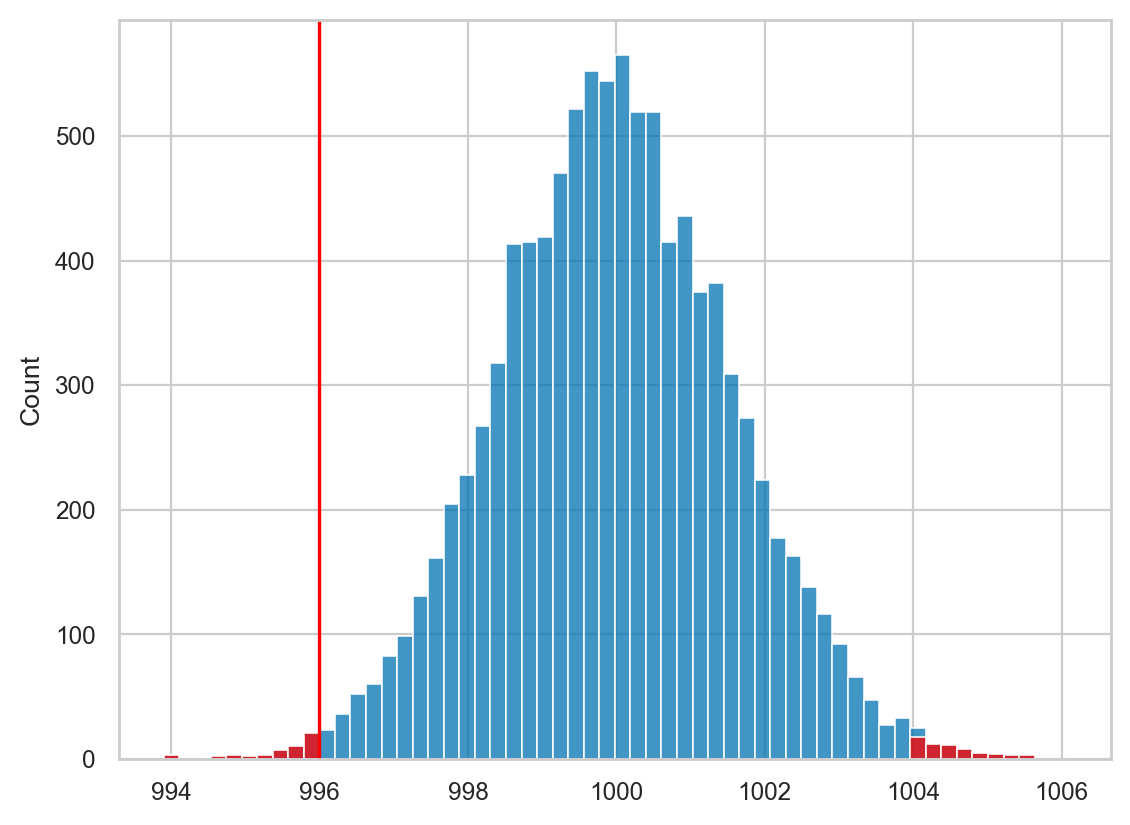

In [22]:
# Choose bins for the histogram aligned with `obsmean06`
from ministats import nicebins
bins = nicebins(kbars40, obsmean06)

# Plot showing `obsmean06` fits within the sampling distribution under H0
sns.histplot(kbars40, bins=bins)
plt.axvline(obsmean06 , color="red")
sns.histplot(tails, bins=bins, color="red");

The function `simulation_test_mean` from the `ministats` library
performs all the steps of the simulation test for the mean.
We can use this function to check we got the above calculations right.

In [23]:
# ALT. Use the pre-defined function `simulation_test_mean`
# Set the random seed to the same value as above to reproduce result
np.random.seed(43)

# Check answer using `ministats` helper function
from ministats import simulation_test_mean
simulation_test_mean(ksample06, mu0=1000, sigma0=10)

0.0125

In [24]:
# Point estimate for the effect size
obsmean06 - 1000

-4.004500000000007

In [26]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# Construct a 90% confidence interval for the effect size
from ministats import ci_mean
cimu06 = ci_mean(ksample06, alpha=0.1, method="b")
ciDelta06 = [cimu06[0]-1000, cimu06[1]-1000]
ciDelta06

[-6.765137500000037, -1.335712500000227]

### E3.25

Run the test for the variance on Batch 01.

In [27]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample01 = kombucha[kombucha["batch"]==1]["volume"]
len(ksample01)

40

In [28]:
ksample01.head()

0    1016.24
1     993.88
2     994.72
3     989.27
4    1008.65
Name: volume, dtype: float64

In [29]:
# Define the variance estimator function
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

In [31]:
# Compute the observed variance
obsvar01 = var(ksample01)
obsvar01

95.4365419871796

In [33]:
# Population data model under H0
from scipy.stats import norm
rvK0 = norm(1000, 10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kvars40 = gen_sampling_dist(rvK0, estfunc=var, n=40)

# Compute the p-value of `obsvar01` under H0
tail = [v for v in kvars40 if v >= obsvar01]
pvalue01 = len(tail) / len(kvars40)
pvalue01

0.5451

The $p$-value is greater than $\alpha=0.05$
so we fail to reject $H_0$.

Let's plot the sampling distribution $S_{\mathbf{K}_0}^2$
under $H_0$ and the observed sample mean $s_{\mathbf{k}_{05}}^2$.

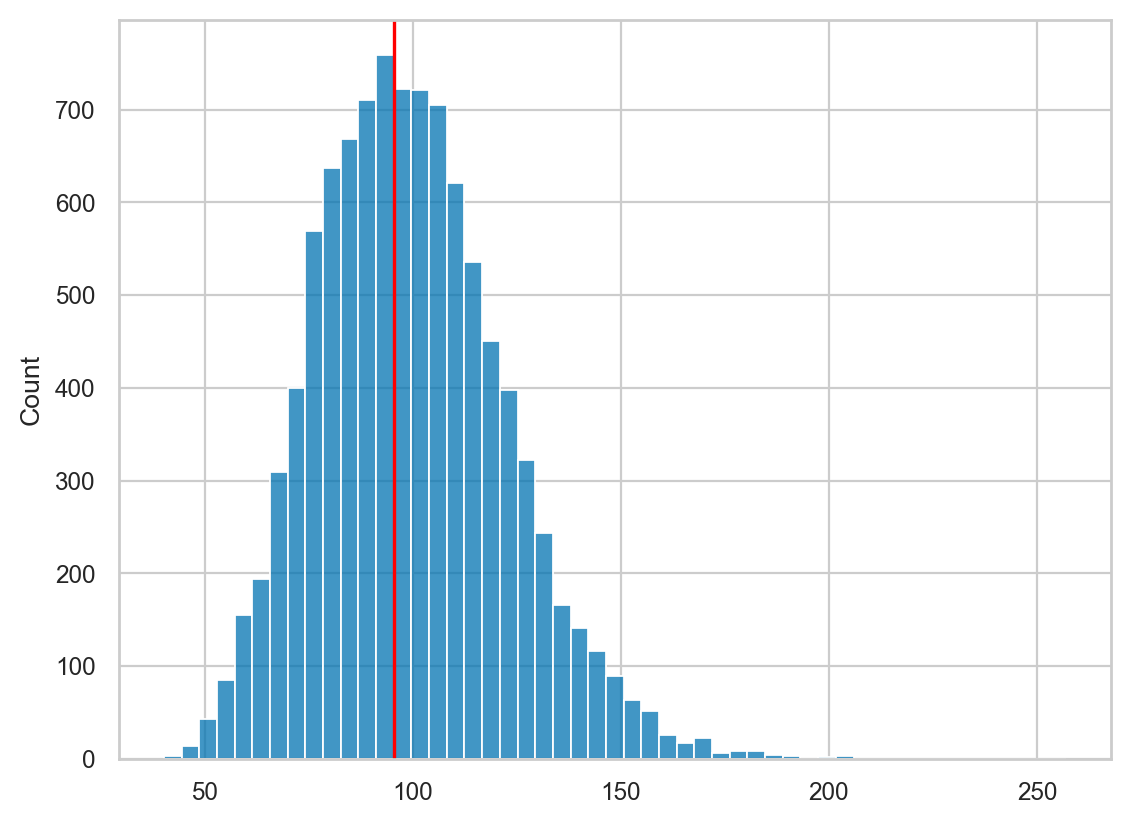

In [34]:
# Choose bins for the histogram aligned with `obsvar01`
from ministats import nicebins
bins = nicebins(kvars40, obsvar01)

# Show where `obsvar01` fits within the sampling distribution under H0
sns.histplot(kvars40, bins=bins)
plt.axvline(obsvar01 , color="red")
sns.histplot(tails, bins=bins, color="red");

The function `simulation_test_var` from the `ministats` library
performs all the steps of the simulation test for the variance.
We can use this function to check we got the above calculations right.

In [35]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Check answer using `ministats` helper function
from ministats import simulation_test_var
simulation_test_var(ksample01, mu0=1000, sigma0=10)

0.5451

### E3.26



In [36]:
from scipy.stats import norm

Delta = 1   # true effect size
rvI = norm(100+Delta, 1)

n = 10

np.random.seed(76)
isample_raw = rvI.rvs(n)
isample = isample_raw.round(1)
print(isample.mean().round(3), isample.std().round(3))
print(isample)

100.88 0.801
[101.9 100.4  99.9 100.4 101.1 100.8 100.8 101.2  99.8 102.5]


In [37]:
# The observed data sample
isample = [101.9, 100.4,  99.9, 100.4, 101.1,
           100.8, 100.8, 101.2,  99.8, 102.5]

In [39]:
# Compute the observed variance
obsimean = np.mean(isample)
obsimean

100.88

In [41]:
# Population data model under H0
from scipy.stats import norm
rvI0 = norm(100, 1)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(46)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
ibars10 = gen_sampling_dist(rvI0, estfunc=np.mean, n=10)

# Compute the p-value of `obsimean` under H0
obsdev = abs(obsimean - 100)
tails = [v for v in ibars10 if abs(v-100) >= obsdev]
pvalue = len(tails) / len(ibars10)
pvalue

0.0058

In [42]:
np.random.seed(46)
# Check answer using `ministats` helper function
from ministats import simulation_test_mean
simulation_test_mean(isample, mu0=100, sigma0=1)

0.0059

### E3.27



In [43]:
bsample = [15, 14,  9, 10, 11, 19, 10, 12, 12, 11,  8, 15]

In [44]:
from scipy.stats import poisson

Delta = 1   # true effect size
rvB = poisson(mu=10+Delta)

n = 12

np.random.seed(44)
bs = rvB.rvs(n)
print(bs.mean().round(3), bs.std().round(3))
list(bs)

12.167 2.967


[15, 14, 9, 10, 11, 19, 10, 12, 12, 11, 8, 15]

In [46]:
# Compute the observed mean
obsbmean = np.mean(bsample)
obsbmean

12.166666666666666

In [48]:
# Population data model under H0
from scipy.stats import poisson
rvB0 = poisson(mu=10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(47)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
bbars12 = gen_sampling_dist(rvB0, estfunc=np.mean, n=12)

# Compute the p-value of `obsbmean` under H0
tail = [v for v in bbars12 if v >= obsbmean]
pvalue = len(tail) / len(bbars12)
pvalue

0.0116

### E3.28




In [49]:
# Observed deflection measurements
dsample = [0.63, 1.12, 1.61, 2.10, 2.59]

In [51]:
# a) Compute the observed mean
obsdmean = np.mean(dsample)
obsdmean

1.61

In [53]:
# Population data model under H0 (Newtonian physics)
from scipy.stats import norm
rvD0 = norm(0.87, 0.99)

# Set the random seed to get a reproducible result
np.random.seed(46)

# b) Generate the sampling distribution of the mean under H0
from ministats import gen_sampling_dist
dbars5 = gen_sampling_dist(rvD0, estfunc=np.mean, n=5)

In [55]:
# c) Compute the one-sided p-value under H0
tail = [dbar for dbar in dbars5 if dbar >= obsdmean]
pvalue = len(tail) / len(dbars5)
pvalue

0.0495

In [56]:
# ALT. Compute the p-value using the Z-test,
#      which we'll describe in the next section.
# # Compute the standard error and z-statistic
# se = 0.99 / np.sqrt(5)
# zscore = (obsdmean - 0.87) / se
# # Compute the one-sided p-value
# pvalue = 1 - norm(0,1).cdf(zscore)
# pvalue

### E3.29

See PDF

